In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import pandas as pd

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter


import marsilea as ma

In [2]:
adata = sc.read_h5ad('/data/users/zhoutao3/online/07.3d/Script/0314/adata.noMenings.h5ad')
adata= adata[~adata.obs['region'].isin(['ventricles_I',
 'ventricles_II',
 'ventricles_III',
 'ventricles_IV'])]

In [3]:
adatas = []
for i in set(adata.obs['slices']):
    temp = adata[adata.obs['slices'] == i].copy()
    sc.pp.normalize_total(temp)
    sc.pp.log1p(temp)
    sc.pp.scale(temp, zero_center=False, max_value=10)
    adatas.append(temp)
adata = ad.concat(adatas)

In [4]:
adata = adata[adata.obs.sample(frac = 0.1).index].copy()

In [5]:
from sklearn.ensemble import RandomForestClassifier
X = adata.X.toarray()
y = adata.obs['region'].tolist()

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X, y)

RandomForestClassifier(random_state=42)

In [7]:
y_pred = rf_model.predict(X)

In [8]:
adata.obs['y_pred'] = y_pred

In [10]:
from sklearn.metrics import confusion_matrix

In [11]:
# 提取真实标签和预测标签
true_labels = adata.obs['region']
pred_labels = adata.obs['y_pred']

In [19]:
cm = confusion_matrix(true_labels, pred_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
unique_labels = sorted(set(true_labels).union(set(pred_labels)))

cm_df = pd.DataFrame(cm_normalized, index=unique_labels, columns=unique_labels)

In [20]:
cm_df

,Striatum,areae_octavolateralis,cerebellum_area,cerebral,choroid_plexus,commissura_interbulbaris,commissura_posterior,corpus_geniculatum_laterale,dorsal_sac,ependyma,...,olfactory_bulb,parapineal_organ,pineal_gland,preoptic_region,primordium_hippocampi,spain_cord,superior_rhombencephalic_reticular_centre,tectum_mesencephali,thalamus,tuberculum_posterius
Striatum,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
areae_octavolateralis,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cerebellum_area,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
cerebral,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
choroid_plexus,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
commissura_interbulbaris,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
commissura_posterior,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
corpus_geniculatum_laterale,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dorsal_sac,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ependyma,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
orders = ['cerebral', 'olfactory_bulb', 'primordium_hippocampi', 'preoptic_region', 'Striatum', 'dorsal_sac', 'commissura_interbulbaris', # #B6282C
'hypothalami_nucleus', 'corpus_geniculatum_laterale', 'pineal_gland', 'tuberculum_posterius', 'ganglia_habenulae', # #E7CF24
          'thalamus', 'fasciculus_retroflexus', 'commissura_posterior', 'neurohypophysis', 'parapineal_organ', 'nervus_pinealis',  # #E7CF24
'tectum_mesencephali', 'nucleus_tegmentalis_lateralis', 'nucleus_interpeduncularis', 'nucleus_reticularis_mesencephali', # #0C6CB2
'cerebellum_area', 'nucleus_cerebelli',  # #852482
'nucleus_of_the_radix_descendens_nervi_trigemini', 'areae_octavolateralis', 'motor_nucleus_of_VII', 'motor_nucleus_of_V', # #B50F58
          'lobus_vagi', 'spain_cord', 'nucleus_of_X', 'middle_superior_rhombencephalic_reticular_centre', 'inferior_rhombencephalic_reticular_centres',# #B50F58
          'superior_rhombencephalic_reticular_centre', 'griseum_centrale_rhombencephali',  # #B50F58
'ependyma', # #A4A7A8
          'choroid_plexus',] # #691317]
jaccard_df = cm_df.reindex(index=orders, columns=orders)

lineage_colors = ['#B6282C', '#B6282C', '#B6282C', '#B6282C', '#B6282C', '#B6282C', '#B6282C', # #B6282C
'#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', # #E7CF24
          '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24', '#E7CF24',  # #E7CF24
'#0C6CB2', '#0C6CB2', '#0C6CB2', '#0C6CB2', # #0C6CB2
'#852482', '#852482',  # #852482
'#B50F58', '#B50F58', '#B50F58', '#B50F58', # #B50F58
          '#B50F58', '#B50F58', '#B50F58', '#B50F58', '#B50F58',# #B50F58
          '#B50F58', '#B50F58',  # #B50F58
'#A4A7A8', # #A4A7A8
          '#691317',] # #691317]

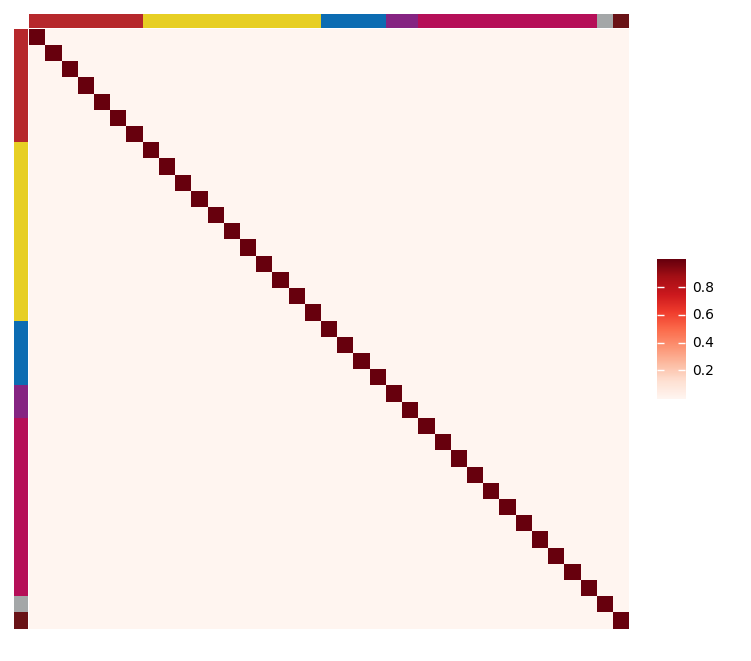

In [22]:
gene_profile = ma.Heatmap(
        jaccard_df,
        # color=dataset["gene_exp_matrix"],
        height=6,
        width=6,
        # cluster_data=cluster_data,
        # marker="P",
        cmap="Reds",
    )
# gene_profile.group_rows(lineage_cells, order=lineage)
gene_profile.group_rows(orders, order=orders,spacing = 0)
gene_profile.add_left(ma.plotter.Chunk(texts = [' ' for i in range(len(orders))], 
                                       padding=0, 
                                       fill_colors = lineage_colors, 
                                       borderwidth = 0),
                      pad=0.01)
gene_profile.group_cols(orders, order=orders,spacing = 0)
gene_profile.add_top(ma.plotter.Chunk(texts = [' ' for i in range(len(orders))], 
                                       padding=0, 
                                       fill_colors = lineage_colors, 
                                       borderwidth = 0),
                      pad=0.01)
# gene_profile.add_dendrogram(
#     "left",
#     method="ward",
#     colors=lineage_colors,
#     meta_color="#451952",
#     linewidth=1.5,
# )
gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()
# gene_profile.save("jaccard.png")

plt.savefig("RandomForest.pdf", bbox_inches="tight")